In [33]:
import pandas as pd
import numpy as np

# feature egineering

# models
from sklearn.linear_model import LogisticRegression

# pipeline

# cloudpicker
from cloudpickle import load

import os

### Terminal

In [6]:
%pwd

'/Users/rahulshelke/Documents/Data-Science/Data-Science-Projects/heart-stroke-prediction'

### Load Data

In [9]:
DATA_PATH = os.path.join("notebooks", "data")
ARTIFACT_PATH = os.path.join("notebooks", "artifacts")

In [12]:
os.path.exists(DATA_PATH), os.path.exists(ARTIFACT_PATH)

(True, True)

In [14]:
os.listdir(DATA_PATH)

['heart_stroke_data_handled_missing_values.csv',
 'heart_stroke_data_full_num.csv',
 'heart_stroke_data_handled_outliers.csv',
 'heart_stroke_data.csv',
 'healthcare-dataset-stroke-data.csv',
 'heart_stroke_feature_engineered_data.csv']

In [16]:
DATA_FILES = os.listdir(DATA_PATH)

In [35]:
df = pd.read_csv(os.path.join(DATA_PATH, DATA_FILES[-2]))

In [36]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [20]:
df.shape

(5110, 12)

### Load Artifacts

In [21]:
os.listdir(ARTIFACT_PATH)

['pipeline_functions.py',
 'missing_imputer_pipeline_v1.pkl',
 'data_correction_pipeline_v1.pkl',
 'data_correction_pipeline_v2.pkl',
 '__pycache__',
 'feature_engineering_pipeline_v1.pkl',
 'imputer_pipeline_v1.pkl']

In [22]:
ARTIFACT_FILES = os.listdir(ARTIFACT_PATH)

In [37]:
with open(os.path.join(ARTIFACT_PATH, ARTIFACT_FILES[-2]), "rb") as f:
    preprocessor = load(f)

In [38]:
preprocessor

/Users/rahulshelke/Documents/Data-Science/Data-Science-Projects/heart-stroke-prediction/.venv/lib/python3.11/site-packages/sklearn/externals/_numpydoc/docscrape.py:420: UserWarning: Unknown section Responsibility
  self[section] = content
/Users/rahulshelke/Documents/Data-Science/Data-Science-Projects/heart-stroke-prediction/.venv/lib/python3.11/site-packages/sklearn/externals/_numpydoc/docscrape.py:420: UserWarning: Unknown section Bahviour
  self[section] = content
/Users/rahulshelke/Documents/Data-Science/Data-Science-Projects/heart-stroke-prediction/.venv/lib/python3.11/site-packages/sklearn/externals/_numpydoc/docscrape.py:420: UserWarning: Unknown section Examples:
  self[section] = content


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('correct_column_names', ...), ('correct_column_values', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,mapping,{'Residence_type': 'residence_type'}
,column_mappings,"{'ever_married': {'No': 'no', 'Yes': 'yes'}, 'gender': {'Female': 'female', 'Male': 'male', 'Other': 'other'}, 'residence_type': {'Rural': 'rural', 'Urban': 'urban'}, 'smoking_status': {'Unknown': 'unknown', 'formerly smoked': 'formerly_smoked', 'never smoked': 'never_smoked'}, ...}"
,missing_tokens,['unknown']
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting

In [50]:
preprocessor.set_output(transform="pandas")

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('correct_column_names', ...), ('correct_column_values', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,mapping,{'Residence_type': 'residence_type'}
,column_mappings,"{'ever_married': {'No': 'no', 'Yes': 'yes'}, 'gender': {'Female': 'female', 'Male': 'male', 'Other': 'other'}, 'residence_type': {'Rural': 'rural', 'Urban': 'urban'}, 'smoking_status': {'Unknown': 'unknown', 'formerly smoked': 'formerly_smoked', 'never smoked': 'never_smoked'}, ...}"
,missing_tokens,['unknown']
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting

In [75]:
X = preprocessor.fit_transform(df).drop(['id', 'stroke'], axis='columns')
y = df['stroke']

In [78]:
X.head()

,age_glucose,age_bmi,bmi,avg_glucose_level,hypertension,heart_disease,gender_male,gender_infrequent_sklearn,ever_married_yes,work_type_govt_job,work_type_never_worked,work_type_private,work_type_self_employed,residence_type_urban,smoking_status_never_smoked,smoking_status_smokes
0,1.923686,1.079811,0,0,0,1,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,1.340388,0.021263,0,0,0,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0.613025,0.912699,0,0,0,1,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,0.416906,0.232725,0,0,0,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
4,2.229024,-0.879067,0,0,1,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [77]:
X.columns

Index(['age_glucose', 'age_bmi', 'bmi', 'avg_glucose_level', 'hypertension',
       'heart_disease', 'gender_male', 'gender_infrequent_sklearn',
       'ever_married_yes', 'work_type_govt_job', 'work_type_never_worked',
       'work_type_private', 'work_type_self_employed', 'residence_type_urban',
       'smoking_status_never_smoked', 'smoking_status_smokes'],
      dtype='object')

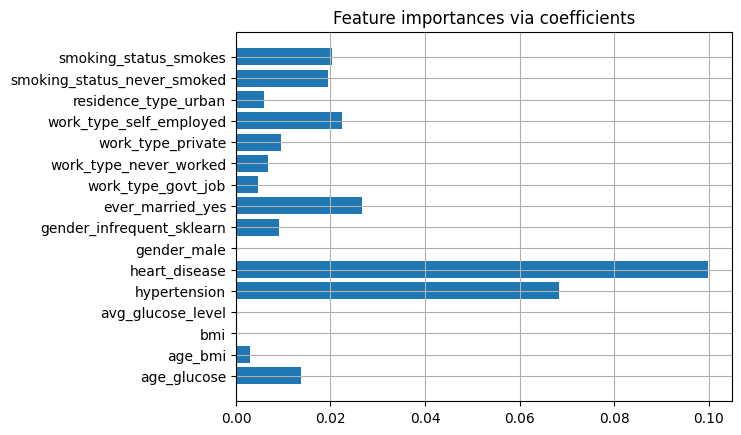

In [70]:
import matplotlib.pyplot as plt

from sklearn.linear_model import RidgeCV

ridge = RidgeCV(alphas=np.logspace(-6, 6, num=5)).fit(X, y)
importance = np.abs(ridge.coef_)
feature_names = np.array(X.columns)
plt.barh(width=importance, y=feature_names)
plt.title("Feature importances via coefficients")
plt.grid(True)
plt.show()

In [71]:
from time import time

from sklearn.feature_selection import SelectFromModel

threshold = np.sort(importance)[-3] + 0.01

tic = time()
sfm = SelectFromModel(ridge, threshold=threshold).fit(X, y)
toc = time()
print(f"Features selected by SelectFromModel: {feature_names[sfm.get_support()]}")
print(f"Done in {toc - tic:.3f}s")

Features selected by SelectFromModel: ['hypertension' 'heart_disease']
Done in 0.015s


In [72]:
from sklearn.feature_selection import SequentialFeatureSelector

tic_fwd = time()
sfs_forward = SequentialFeatureSelector(
    ridge, n_features_to_select=2, direction="forward"
).fit(X, y)
toc_fwd = time()

tic_bwd = time()
sfs_backward = SequentialFeatureSelector(
    ridge, n_features_to_select=2, direction="backward"
).fit(X, y)
toc_bwd = time()

print(
    "Features selected by forward sequential selection: "
    f"{feature_names[sfs_forward.get_support()]}"
)
print(f"Done in {toc_fwd - tic_fwd:.3f}s")
print(
    "Features selected by backward sequential selection: "
    f"{feature_names[sfs_backward.get_support()]}"
)
print(f"Done in {toc_bwd - tic_bwd:.3f}s")

Features selected by forward sequential selection: ['age_glucose' 'age_bmi']
Done in 0.215s
Features selected by backward sequential selection: ['smoking_status_never_smoked' 'smoking_status_smokes']
Done in 1.326s


In [76]:
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

for tol in [-1e-2, -1e-3, -1e-4]:
    start = time()
    feature_selector = SequentialFeatureSelector(
        LogisticRegression(),
        n_features_to_select="auto",
        direction="backward",
        scoring="roc_auc",
        tol=tol,
        n_jobs=2,
    )
    model = make_pipeline(StandardScaler(), feature_selector, LogisticRegression())
    model.fit(X, y)
    end = time()
    print(f"\ntol: {tol}")
    print(f"Features selected: {feature_names[model[1].get_support()]}")
    print(f"ROC AUC score: {roc_auc_score(y, model.predict_proba(X)[:, 1]):.3f}")
    print(f"Done in {end - start:.3f}s")


tol: -0.01


IndexError: boolean index did not match indexed array along axis 0; size of axis is 30 but size of corresponding boolean axis is 16